In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd
# Import Matplotlib's pyplot module for creating visualizations
import matplotlib.pyplot as plt
# Import Seaborn for statistical data visualization
import seaborn as sns
df = pd.read_csv("1) iris.csv")
# Display the first five rows of the dataset
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


<Figure size 640x480 with 0 Axes>

In [2]:
# Display information about the DataFrame
# This includes the number of rows, columns, non-null values, and data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [3]:
#Count the number of missing values in each column
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [4]:
# Calculate the percentage of missing values in each column
missing_percent = df.isnull().mean() * 100
# Display the percentage of missing values
print(missing_percent)

sepal_length    0.0
sepal_width     0.0
petal_length    0.0
petal_width     0.0
species         0.0
dtype: float64


In [5]:
# Count the number of duplicated rows in the dataset
print( df.duplicated().sum())

3


In [6]:
# Remove duplicated rows from the dataset
df = df.drop_duplicates()
# Display the number of rows remaining after removing duplicates
print( len(df))

147


In [7]:
# Display all unique values in the species column
print(df["species"].unique())

['setosa' 'versicolor' 'virginica']


In [8]:
# Count the number of observations belonging to each species
print(df["species"].value_counts())

versicolor    50
virginica     49
setosa        48
Name: species, dtype: int64


In [9]:
# Remove unnecessary spaces from the species values
# and convert all species names to lowercase
df["species"] = df["species"].str.strip().str.lower()
# Display the standardized species categories

print(df["species"].unique())

['setosa' 'versicolor' 'virginica']


In [10]:
# Remove any duplicates that may have appeared after preprocessing
df = df.drop_duplicates()

In [11]:
# Display the final number of rows
print(df.shape)

(147, 5)


In [12]:
numeric_columns = df.select_dtypes(include="number").columns

mean = df[numeric_columns].mean()
median = df[numeric_columns].median()
mode = df[numeric_columns].mode().iloc[0]
std = df[numeric_columns].std()

summary = pd.DataFrame({
    "Mean": mean,
    "Median": median,
    "Mode": mode,
    "Standard Deviation": std
})

print(summary)

                  Mean  Median  Mode  Standard Deviation
sepal_length  5.856463     5.8   5.0            0.829100
sepal_width   3.055782     3.0   3.0            0.437009
petal_length  3.780272     4.4   1.4            1.759111
petal_width   1.208844     1.3   0.2            0.757874


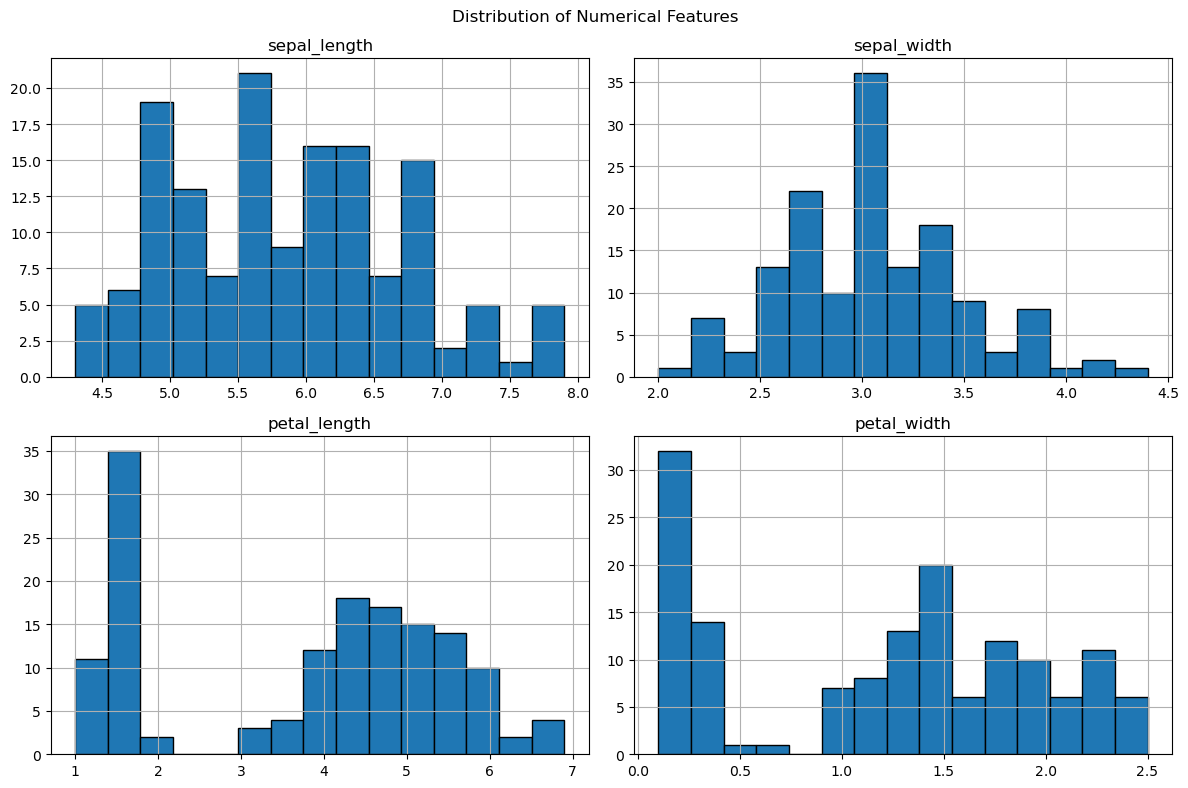

In [13]:
df[numeric_columns].hist(
    figsize=(12, 8),
    bins=15,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.savefig('distribution_numerical_features.png', dpi=150, facecolor='white')
plt.show()

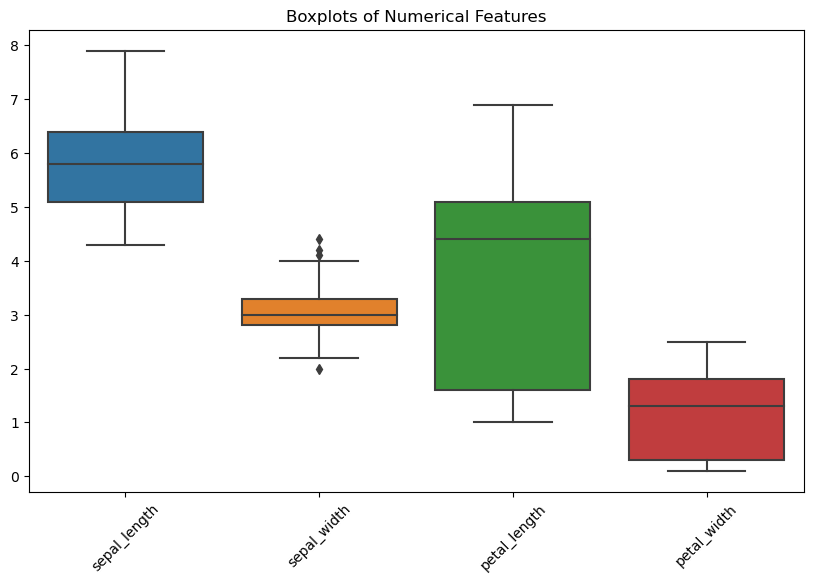

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[numeric_columns])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.savefig('boxplots_numerical_features.png', dpi=150, facecolor='white')
plt.show()

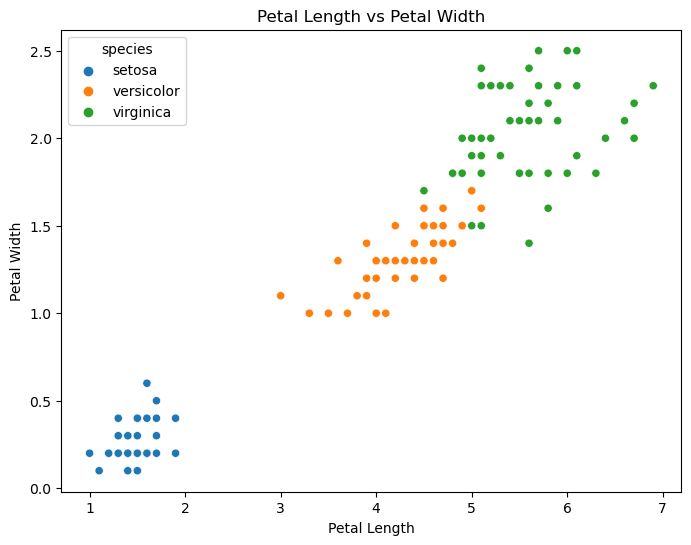

In [15]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species"
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.savefig('petal_length_vs_petal_width.png', dpi=150, facecolor='white')
plt.show()

In [16]:
correlation = df[numeric_columns].corr()

print(correlation)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109321      0.871305     0.817058
sepal_width      -0.109321     1.000000     -0.421057    -0.356376
petal_length      0.871305    -0.421057      1.000000     0.961883
petal_width       0.817058    -0.356376      0.961883     1.000000


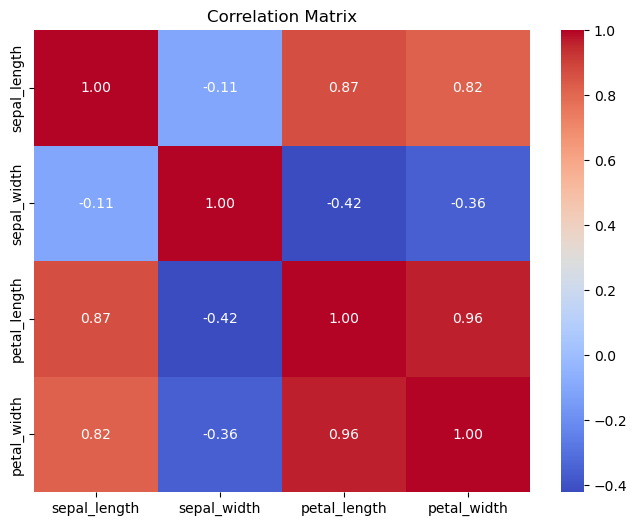

In [17]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.savefig('correlation_matrix.png', dpi=150, facecolor='white')
plt.show()

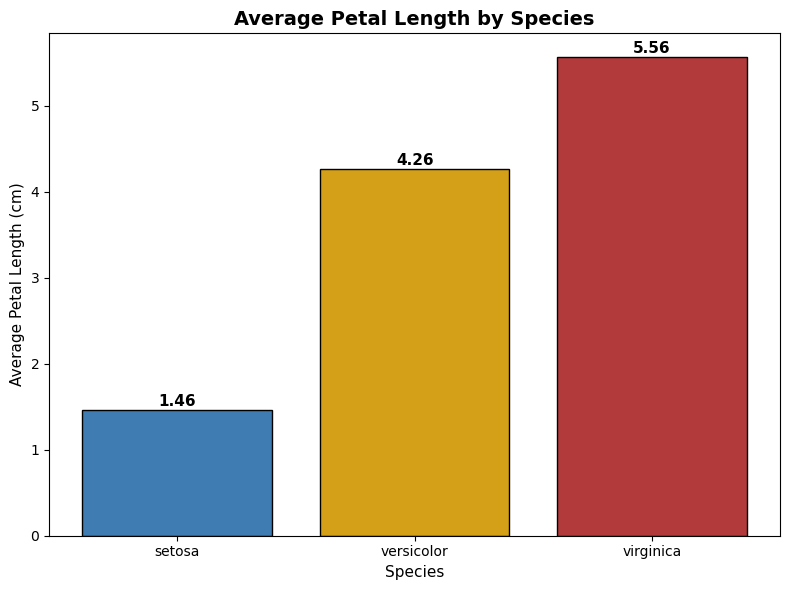

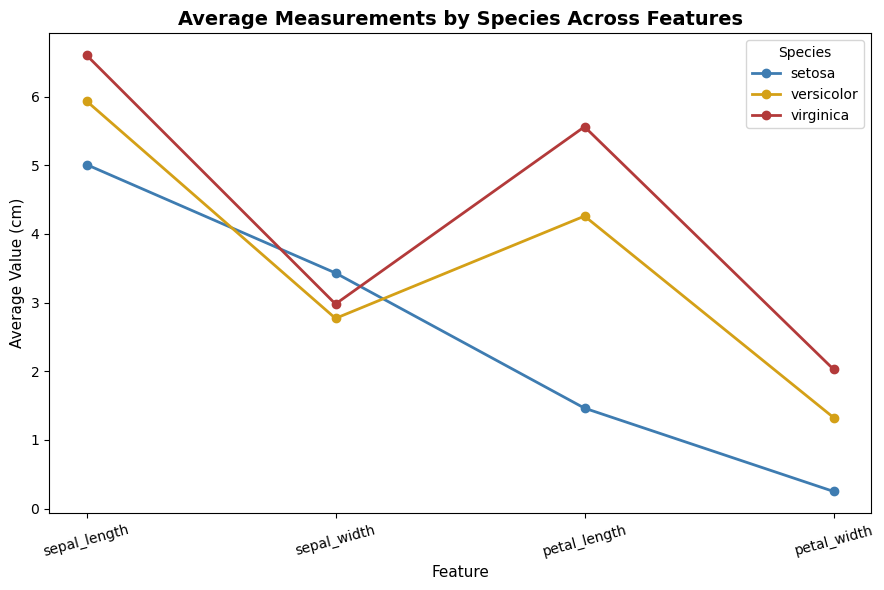

In [18]:
# --- BAR PLOT: Average Petal Length by Species ---
avg_petal = df.groupby('species')['petal_length'].mean().sort_values()

colors_species = {'setosa': '#3E7CB1', 'versicolor': '#D4A017', 'virginica': '#B33A3A'}

plt.figure(figsize=(8, 6))
bars = plt.bar(avg_petal.index, avg_petal.values,
                color=[colors_species[s] for s in avg_petal.index], edgecolor='black')

for bar, v in zip(bars, avg_petal.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.2f}',
              ha='center', fontsize=11, fontweight='bold')

plt.title('Average Petal Length by Species', fontsize=14, fontweight='bold')
plt.xlabel('Species', fontsize=11)
plt.ylabel('Average Petal Length (cm)', fontsize=11)
plt.tight_layout()
plt.savefig('bar_plot_petal_length_by_species.png', dpi=150, facecolor='white')
plt.savefig('average_petal_length_by_species.png', dpi=150, facecolor='white')
plt.show()


# --- LINE CHART: Average Measurements by Species Across Features ---
numeric_columns = df.select_dtypes(include="number").columns
species_means = df.groupby('species')[numeric_columns].mean()

plt.figure(figsize=(9, 6))
for species in species_means.index:
    plt.plot(numeric_columns, species_means.loc[species], marker='o',
              label=species, color=colors_species[species], linewidth=2)

plt.title('Average Measurements by Species Across Features', fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=11)
plt.ylabel('Average Value (cm)', fontsize=11)
plt.legend(title='Species', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('line_chart_avg_measurements_by_species.png', dpi=150, facecolor='white')
plt.savefig('average_measurements_by_species.png', dpi=150, facecolor='white')
plt.show()